In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load data
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append('../')
# from utils.data import *
from utils import data, metrics
server_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/approxineuro'
# load 100 neuron recordings (for one mouse)

mouse_id = 7
train_model = False
save_path = f'/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}.npz'

# train gabor model

In [17]:
# load images
data_path = '../data'

# load neurons
fname = '%s_nat30k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id)
n_stim, n_max_neurons = spks.shape
print(len(spks_rep_all))

# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
ineur = np.arange(0, n_max_neurons) #np.arange(0, n_neurons, 5)

# normalize spks
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)
spks_val = torch.from_numpy(spks[ival][:,ineur]) 
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]

# ineurons = np.arange(data.NNs_valid[mouse_id])
# ineurons = np.arange(0, n_max_neurons, 1)
# np.random.seed(42)
# ineurons = np.random.choice(ineurons, 100, replace=False)

# fev_test = metrics.fev(spks_rep_all)
# isort_neurons = np.argsort(fev_test)[::-1]
# ineur = isort_neurons[ineurons]

print(spks.shape, spks_val.shape, len(spks_rep_all), spks_rep_all[0].shape)

spks = spks[:,ineur]
spks_val = spks_val[:,ineur]
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]
print(spks.shape, spks_val.shape, len(spks_rep_all), spks_rep_all[0].shape)

n_stim, n_neurons = spks.shape


loading activities from ../data/FX41_nat30k_2025_01_23.npz
500

splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (16838,)
ival:  (1871,)

normalizing neural data...


In [ ]:


img_all = data.load_images(data_path, file=os.path.join(data_path, data.img_file_name[mouse_id]), downsample=2, crop=False)
nimg, Ly, Lx = img_all.shape
print('img: ', img_all.shape, img_all.min(), img_all.max())

n_stim = -1 # spks.shape[0]
n_neurons = -1

# generate random data
if n_stim > 0:
    istims = np.random.choice(spks.shape[0], n_stim, replace=False)
else:
    n_stim = spks.shape[0]
    istims = np.arange(n_stim)
if n_neurons > 0:
    ineurons = np.random.choice(spks.shape[1], n_neurons, replace=False)
    X_test = [spks_rep_all[i][:,ineurons] for i in range(len(spks_rep_all))]
else:
    n_neurons = spks.shape[1]
    ineurons = np.arange(n_neurons)
    X_test = spks_rep_all.copy()
# ineurons = np.random.choice(spks.shape[1], n_neurons, replace=False)
# ineurons = np.arange(n_neurons)
X = spks[istims][:,ineurons]
# X = spks.copy()
# Ly, Lx = 6, 13
# img = np.random.randn(Ly, Lx, n_stim)
# # normalize
# img = (img - img.mean()) / img.std()
img = img_all[istim_train][istims].transpose(1,2,0)
# img_mean = img.mean()
# img_std = img.std()
# img = (img - img.mean()) / img.std()
img_test = img_all[istim_test].transpose(1,2,0)
print(f'img: {img.shape}, X: {X.shape}')
Ly, Lx, _ = img.shape

if train_model:
    from utils import gabor
    result_dict = gabor.fit_gabor_model(X, img, X_test, img_test)

    save_path = os.path.join('../weights', 'gabor', f'gabor_params_{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}.npz')
    np.savez(save_path, **result_dict)
else:
    result_dict = np.load(save_path, allow_pickle=True)

raw image shape:  (68032, 66, 264)
image mean:  126.714066
image std:  57.67655
img:  (68032, 33, 132) -2.1969771 2.2242303
img: (33, 132, 21227), X: (21227, 5196)


xmax: (5196,), 1, 131
ymax: (5196,), 0, 31


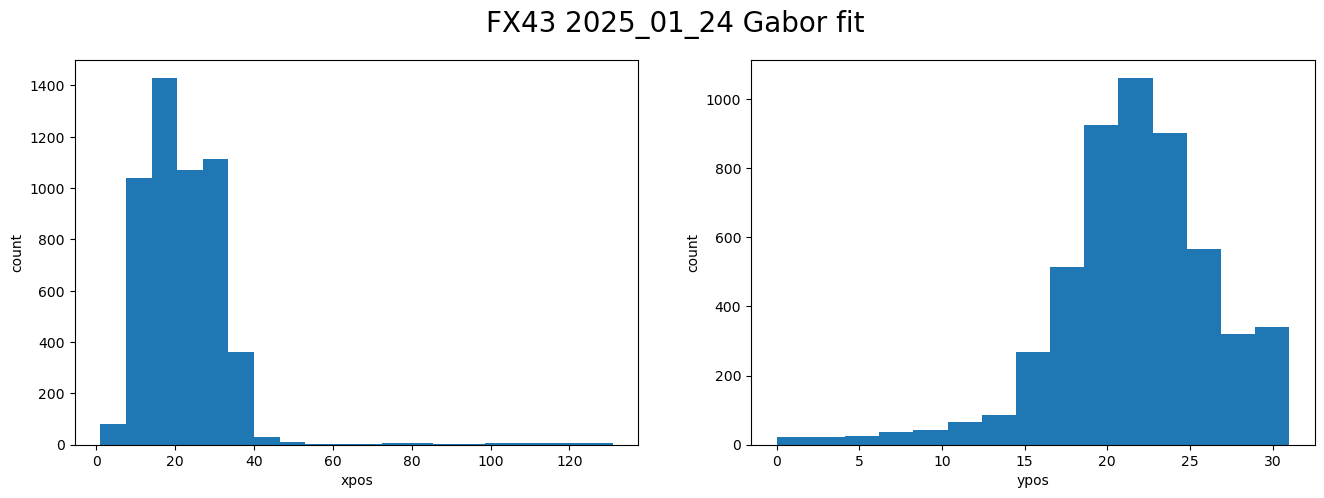

In [ ]:
xmax, ymax = result_dict['xmax'], result_dict['ymax']
print(f'xmax: {xmax.shape}, {xmax.min()}, {xmax.max()}')
print(f'ymax: {ymax.shape}, {ymax.min()}, {ymax.max()}')
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
# distribution
ax[0].hist(xmax, bins=20)
ax[0].set_xlabel('xpos')
ax[0].set_ylabel('count')
ax[1].hist(ymax, bins=15)
ax[1].set_xlabel('ypos')
ax[1].set_ylabel('count')
plt.suptitle(f'{data.db[mouse_id]["mname"]} {data.db[mouse_id]["datexp"]} Gabor fit', fontsize=20)
plt.show()

In [ ]:
test_fev, test_feve = result_dict['fev'], result_dict['feve']
print('FEV (test): ', np.mean(test_fev))
print('FEVE (test): ', np.mean(test_feve))

threshold = 0.01
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')
threshold = 0.15
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

print(f'filtering neurons with FEV < {threshold} and FEV > 0.01')
valid_idxes = np.where((test_fev < threshold) & (test_fev >0.01))[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[valid_idxes])}')

FEV (test):  0.119300075
FEVE (test):  0.23668803
filtering neurons with FEV > 0.01
valid neurons: 4841 / 5196
FEVE (test): 0.25941336154937744
filtering neurons with FEV > 0.15
valid neurons: 1655 / 5196
FEVE (test): 0.31763389706611633
filtering neurons with FEV < 0.15 and FEV > 0.01
valid neurons: 3186 / 5196
FEVE (test): 0.22917011380195618


xmax: (5196,), 1, 131
ymax: (5196,), 0, 31


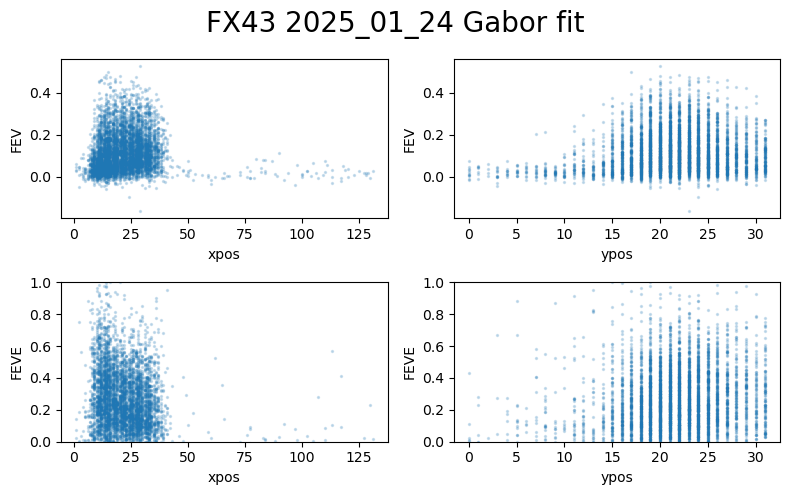

In [ ]:
xmax, ymax = result_dict['xmax'], result_dict['ymax']
print(f'xmax: {xmax.shape}, {xmax.min()}, {xmax.max()}')
print(f'ymax: {ymax.shape}, {ymax.min()}, {ymax.max()}')
fig, ax = plt.subplots(2, 2, figsize=(8,5))
# distribution
ax[0,0].scatter(xmax, test_fev, s=2, alpha=0.2)
ax[0,0].set_xlabel('xpos')
ax[0,0].set_ylabel('FEV')
ax[0,1].scatter(ymax, test_fev, s=2, alpha=0.2)
ax[0,1].set_xlabel('ypos')
ax[0,1].set_ylabel('FEV')
ax[1,0].scatter(xmax, test_feve, s=2, alpha=0.2)
ax[1,0].set_xlabel('xpos')
ax[1,0].set_ylabel('FEVE')
ax[1,0].set_ylim(0, 1)
ax[1,1].scatter(ymax, test_feve, s=2, alpha=0.2)
ax[1,1].set_xlabel('ypos')
ax[1,1].set_ylabel('FEVE')
ax[1,1].set_ylim(0, 1)
plt.suptitle(f'{data.db[mouse_id]["mname"]} {data.db[mouse_id]["datexp"]} Gabor fit', fontsize=20)
plt.tight_layout()
plt.show()

# test

In [ ]:
# check FEV and FEVE
# check the location (xlocation) distribution
# separate the V1 vs medial neurons
# complex/simple cell distribution

# save_path = f'/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}.npz'

In [ ]:
# define gabor parameters
sigma = np.array([0.75, 1.25, 1.5, 2.5, 3.5, 4.5, 5.5])
f = np.array([0.1, 0.25, 0.5, 1, 2]) #[.01:.02:.13];
theta = np.arange(0, np.pi, np.pi/8)
ph = np.arange(0, 2*np.pi, np.pi/4)
ar = np.array([1, 1.5, 2])
print(f'sigma: {sigma.shape}, f: {f.shape}, theta: {theta.shape}, ph: {ph.shape}, ar: {ar.shape}')

params = np.meshgrid(sigma, f, theta, ph, ar, indexing='ij')
n_gabors = params[0].size
print(f'number of gabors: {n_gabors}')

for i in range(len(params)):
    params[i] = np.expand_dims(params[i], axis=(-2,-1))
    params[i] = torch.from_numpy(params[i].astype('float32'))
sigma, f, theta, ph, ar = params
print(f'sigma: {sigma.shape}, f: {f.shape}, theta: {theta.shape}, ph: {ph.shape}, ar: {ar.shape}')

sigma: (7,), f: (5,), theta: (8,), ph: (8,), ar: (3,)
number of gabors: 6720
sigma: torch.Size([7, 5, 8, 8, 3, 1, 1]), f: torch.Size([7, 5, 8, 8, 3, 1, 1]), theta: torch.Size([7, 5, 8, 8, 3, 1, 1]), ph: torch.Size([7, 5, 8, 8, 3, 1, 1]), ar: torch.Size([7, 5, 8, 8, 3, 1, 1])


In [ ]:
xmax, ymax = result_dict['xmax'], result_dict['ymax']
ys, xs = np.meshgrid(np.arange(0,Ly), np.arange(0,Lx), indexing='ij')
ys, xs = torch.from_numpy(ys.astype('float32')), torch.from_numpy(xs.astype('float32'))
gmax = result_dict['gmax']
gabor_params = torch.zeros((5, n_neurons, 1, 1))
for i in range(len(gabor_params)):
    gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
msigma, mf, mtheta, mph, mar = gabor_params
Amax = result_dict['Amax']
mu1 = torch.from_numpy(result_dict['mu1']).to(device)
mu2 = torch.from_numpy(result_dict['mu2']).to(device)
#  test
ym = torch.from_numpy(ymax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
xm = torch.from_numpy(xmax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
# print(f'ym: {ym.shape}, xm: {xm.shape}')
gabor_params = torch.zeros((5, n_neurons, 1, 1))
for i in range(len(gabor_params)):
    gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
msigma, mf, mtheta, mph, mar = gabor_params
from utils.gabor import gabor_filter, eval_gabors
gabor_filters1 = gabor_filter(ys, xs, ym, xm, 1, msigma, mf, mtheta, mph, mar, is_torch=True).to(device).unsqueeze(-3)
gabor_filters2 = gabor_filter(ys, xs, ym, xm, 1, msigma, mf, mtheta, mph + np.pi/2, mar, is_torch=True).to(device).unsqueeze(-3)

# load test images
# img_test = img_all[istim_test].transpose(1,2,0)
# img_test = (img_test - img_mean) / img_std
# print(f'img_test: {img_test.shape} {img_test.min()}, {img_test.max()}')

# predict responses
ntest = len(istim_test)
resp_test1 = torch.zeros((n_neurons, ntest), dtype=torch.float32, device=device)
resp_test2 = torch.zeros((n_neurons, ntest), dtype=torch.float32, device=device)
eval_gabors(img_test, gabor_filters1, resp_test1, device=device, rectify=False)
eval_gabors(img_test, gabor_filters2, resp_test2, device=device, rectify=False)
resp_test2 = torch.sqrt(resp_test1**2 + resp_test2**2) # RMS for complex cell response
from torch.nn.functional import relu
resp_test2 = relu(resp_test2) # rectify
resp_test1 = relu(resp_test1) # rectify

c = torch.from_numpy(Amax).to(device)

rpred = ((resp_test1.T - mu1) * c[:,0] + (resp_test2.T - mu2) * c[:,1]) # (n_stim, n_neurons)
rpred = rpred.cpu().detach().numpy()
print(f'rpred: {rpred.shape}')

rpred: (500, 5196)


In [ ]:
# test responses
train_mu = result_dict['train_mu']
train_std = result_dict['train_std']
# rpred = result_dict['rpred']
spks_rep_all = X_test.copy()
nreps = []
for i in range(len(spks_rep_all)):
    spks_rep_all[i] -= train_mu
    spks_rep_all[i] /= train_std
    nreps.append(spks_rep_all[i].shape[0])

In [ ]:
fev, feve = metrics.feve(X_test, rpred, nreps)
print(f'fev:{fev.mean():.3f}, feve:{feve.mean():.3f}')

cratio = Amax[:,1]/Amax.sum(axis=1)

fev:0.119, feve:0.237


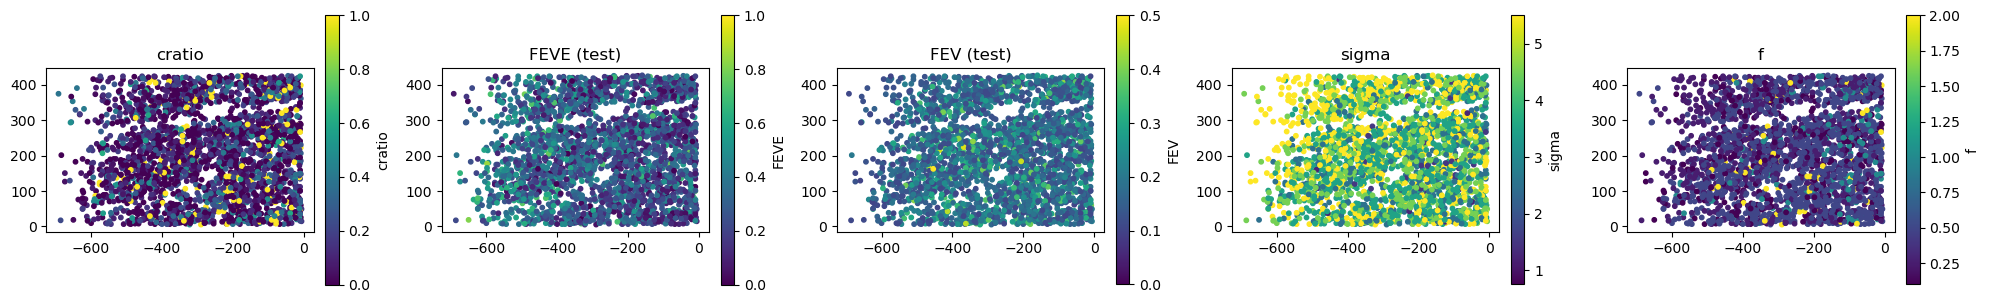

In [ ]:
fig, ax = plt.subplots(1,5, figsize=(20, 5))
pix_res = [.75, .5]

if mouse_id in [5, 7, 11, 13]:
    pix_res = [0.75, 0.5]
elif mouse_id in [15, 16]:
    pix_res = [0.5, 0.5]

valid_idxes = np.where(fev > 0.1)[0]
xpos_plot, ypos_plot  = xpos[valid_idxes]/pix_res[0], ypos[valid_idxes]/pix_res[1]

ax[0].scatter(-ypos_plot, xpos_plot, c=cratio[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
ax[0].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[0].collections[0], ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label('cratio')
ax[0].set_title('cratio')

ax[1].scatter(-ypos_plot, xpos_plot, c=test_feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
ax[1].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[1].collections[0], ax=ax[1], fraction=0.046, pad=0.04)
cbar.set_label('FEVE')
ax[1].set_title('FEVE (test)')

ax[2].scatter(-ypos_plot, xpos_plot, c=fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=0.5)
ax[2].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[2].collections[0], ax=ax[2], fraction=0.046, pad=0.04)
cbar.set_label('FEV')
ax[2].set_title('FEV (test)')

ax[3].scatter(-ypos_plot, xpos_plot, c=msigma[valid_idxes].cpu().numpy(), s=10, cmap='viridis', vmin=0.75, vmax=5.5)
ax[3].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[3].collections[0], ax=ax[3], fraction=0.046, pad=0.04)
cbar.set_label('sigma')
ax[3].set_title('sigma')

ax[4].scatter(-ypos_plot, xpos_plot, c=mf[valid_idxes].cpu().numpy(), s=10, cmap='viridis', vmin=0.1, vmax=2)
ax[4].set_aspect('equal', adjustable='box')
# add colorbar
cbar = fig.colorbar(ax[4].collections[0], ax=ax[4], fraction=0.046, pad=0.04)
cbar.set_label('f')
ax[4].set_title('f')

plt.tight_layout()
plt.show()

In [ ]:
plt.hist(xpos_visual)

NameError: name 'xpos_visual' is not defined

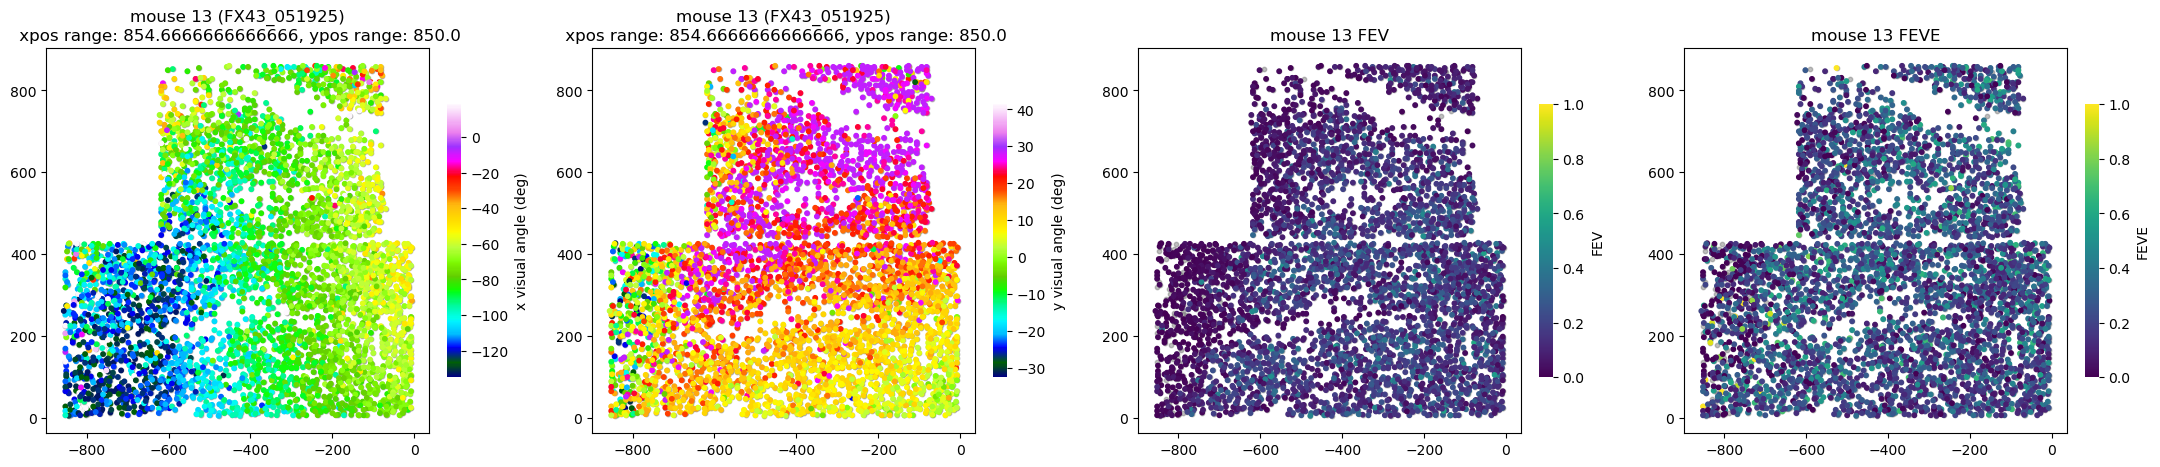

In [ ]:
valid_idxes = np.where(fev > 0.0)[0]
xpos_visual = xmax*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
ypos_visual = ymax*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
xpos_plot, ypos_plot  = xpos/pix_res[0], ypos/pix_res[1]
vmin_x = -135
if mouse_id == 10:  # mouse 11
    vmax_x = 270 * (88/88) - 135
else:  
    vmax_x = 270 * (50/88)-135
vmin_y = -32.5
vmax_y = 65*(25/22)-32.5
fig, ax = plt.subplots(1, 4, figsize=(27, 5))
ax[0].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos_plot, xpos_plot, c=xpos_visual, s=10, cmap='gist_ncar', vmin=vmin_x, vmax=vmax_x, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[0].set_aspect('equal', adjustable='box')
# ax.set_axis_off()
# fig.savefig(f'./outputs/{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_xpos_visual.png', dpi=300, bbox_inches='tight')
# plt.close(fig)
ax[1].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[1].scatter(-ypos_plot, xpos_plot, c=ypos_visual, s=10, cmap='gist_ncar', vmin=vmin_y, vmax=vmax_y, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')
ax[1].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[1].set_aspect('equal', adjustable='box')

ax[2].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[2].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
ax[2].set_title(f'mouse {mouse_id+1} FEV', loc='center')
ax[2].set_aspect('equal', adjustable='box')

ax[3].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[3].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[3], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
ax[3].set_title(f'mouse {mouse_id+1} FEVE', loc='center')
ax[3].set_aspect('equal', adjustable='box')



In [ ]:
d

NameError: name 'd' is not defined

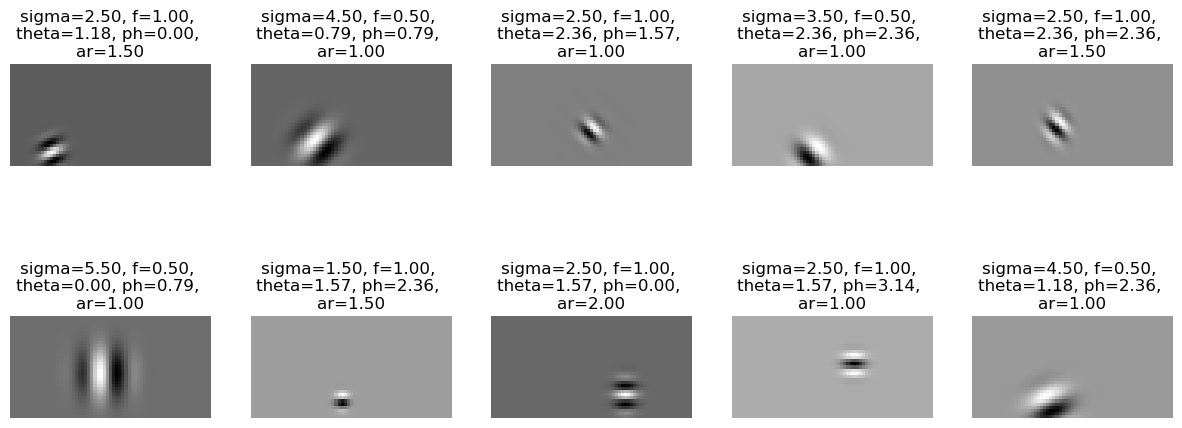

In [ ]:
gabor_filters1.shape
ineurons = np.random.choice(n_neurons, 10, replace=False)
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(2, 5, figsize=(15,6))
for i, axi in enumerate(ax.flat):
    axi.imshow(gabor_filters1[ineurons[i]].cpu().numpy().squeeze(), cmap='gray')
    axi.axis('off')
    axi.set_title(f'sigma={msigma[ineurons[i]].item():.2f}, f={mf[ineurons[i]].item():.2f}, \ntheta={mtheta[ineurons[i]].item():.2f}, ph={mph[ineurons[i]].item():.2f}, \nar={mar[ineurons[i]].item():.2f}')
plt.show()

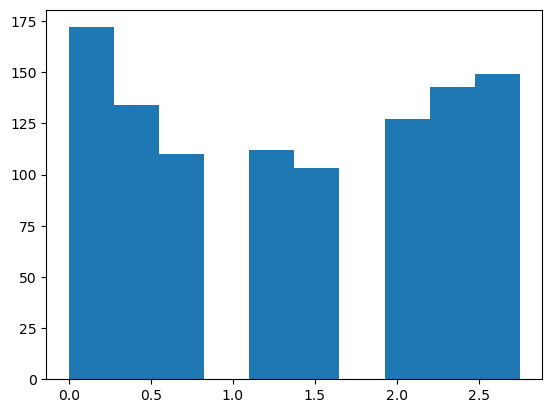

In [ ]:
plt.hist(mtheta.cpu().numpy().flatten())
plt.show()

#complex cells: 477/5196


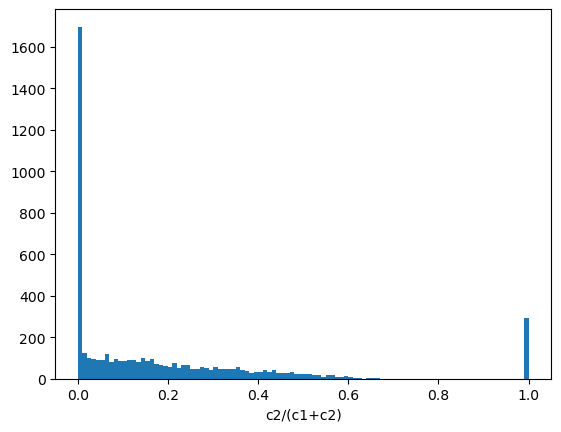

In [ ]:
import matplotlib.pyplot as plt
print(f'#complex cells: {np.sum(cratio > 0.5)}/{n_neurons}')
plt.hist(cratio, bins=100)
plt.xlabel('c2/(c1+c2)')
plt.show()

(-100.0, 100.0)

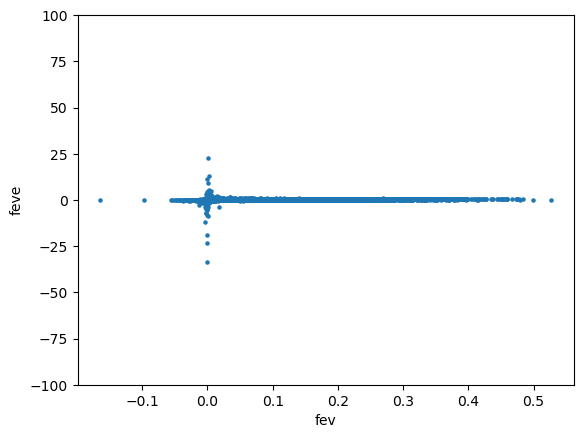

In [ ]:
plt.scatter(fev, feve, s=5)
plt.xlabel('fev')
plt.ylabel('feve')
plt.ylim(-100,100)

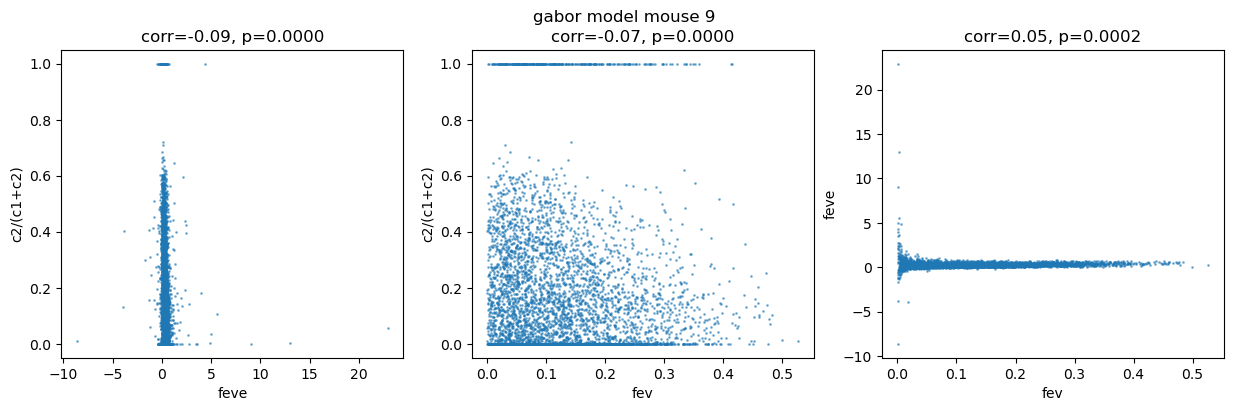

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
valid_idxes = np.where((fev > 0))[0]
ax[0].scatter(feve[valid_idxes], cratio[valid_idxes], s=1, alpha=0.5)
from scipy.stats import pearsonr
corr, p = pearsonr(feve[valid_idxes], cratio[valid_idxes])
ax[0].set_title(f'corr={corr:.2f}, p={p:.4f}')
ax[0].set_xlabel('feve')
ax[0].set_ylabel('c2/(c1+c2)')
ax[1].scatter(fev[valid_idxes], cratio[valid_idxes], s=1, alpha=0.5)
corr, p = pearsonr(fev[valid_idxes], cratio[valid_idxes])
ax[1].set_title(f'corr={corr:.2f}, p={p:.4f}')
ax[1].set_xlabel('fev')
ax[1].set_ylabel('c2/(c1+c2)')
ax[2].scatter(fev[valid_idxes], feve[valid_idxes], s=1, alpha=0.5)
corr, p = pearsonr(fev[valid_idxes], feve[valid_idxes])
ax[2].set_title(f'corr={corr:.2f}, p={p:.4f}')
ax[2].set_xlabel('fev')
ax[2].set_ylabel('feve')
plt.suptitle(f'gabor model mouse {mouse_id+1}')
plt.show()

torch.Size([5247, 1, 1]) tensor(0.1000) tensor(2.)
torch.Size([5247, 1, 1]) tensor(0.7500) tensor(5.5000)
torch.Size([5247, 1, 1]) tensor(0.) tensor(2.7489)


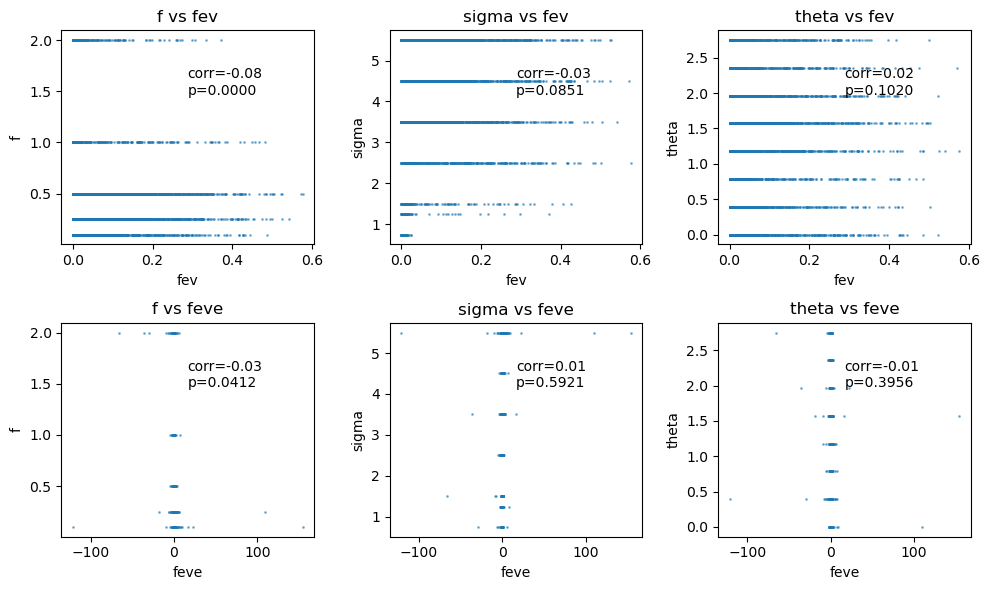

In [ ]:
print(mf.shape, mf.min(), mf.max())
print(msigma.shape, msigma.min(), msigma.max()) # size
print(mtheta.shape, mtheta.min(), mtheta.max()) # orientation
from scipy import stats
fig, ax = plt.subplots(2, 3, figsize=(10,6))
params = [mf.cpu().numpy().squeeze(), msigma.cpu().numpy().squeeze(), mtheta.cpu().numpy().squeeze()]
titles = ['f', 'sigma', 'theta']
# first rwo scatter of params vs fev
for i, axi in enumerate(ax[0]):
    axi.scatter(fev[valid_idxes], params[i][valid_idxes], s=1, alpha=0.5)
    axi.set_ylabel(titles[i])
    axi.set_xlabel('fev')
    axi.set_title(f'{titles[i]} vs fev')
    # pearson correlation and p-value
    corr, p = stats.pearsonr(params[i][valid_idxes], fev[valid_idxes])
    axi.text(0.5, 0.7, f'corr={corr:.2f}\np={p:.4f}', transform=axi.transAxes)

# second row scatter of params vs feve
for i, axi in enumerate(ax[1]):
    axi.scatter(feve[valid_idxes], params[i][valid_idxes], s=1, alpha=0.5)
    axi.set_ylabel(titles[i])
    axi.set_xlabel('feve')
    axi.set_title(f'{titles[i]} vs feve')
    # pearson correlation and p-value
    corr, p = stats.pearsonr(params[i], feve)
    axi.text(0.5, 0.7, f'corr={corr:.2f}\np={p:.4f}', transform=axi.transAxes)
plt.tight_layout()
plt.show()

# fullmodel feve

In [ ]:
# load fullmodel feve
res_dir = '../figures/outputs'
from utils import data
dat = np.load(os.path.join(res_dir, f'fullmodel_{data.mouse_names[mouse_id]}_results.npz'), allow_pickle=True)

fullmodel_feve = dat['fullmodel_feve_all']
nn_all = len(fullmodel_feve)
valid_idxes = dat['valid_idxes']
fullmodel_feve = fullmodel_feve[ineur]

dat = np.load(os.path.join(res_dir, f'minimodel_{data.mouse_names[mouse_id]}_result.npz'), allow_pickle=True)
minimodel_feve = np.inf * np.ones(nn_all)
minimodel_feve[valid_idxes] = dat['feve_all']
minimodel_feve = minimodel_feve[ineur]

print(fullmodel_feve.shape, minimodel_feve.shape)

(3040,) (3040,)


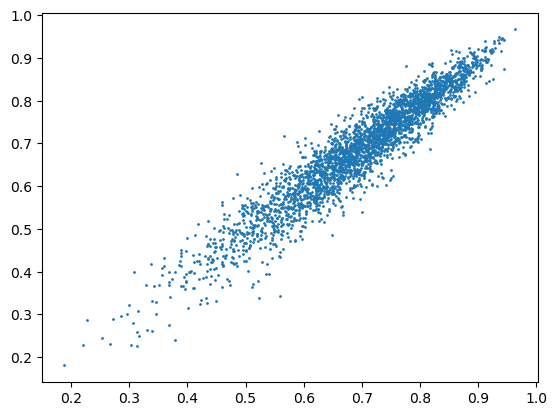

In [ ]:
plt.scatter(fullmodel_feve, minimodel_feve, s=1)

In [ ]:
for k, v in dat.items():
    print(k, v.shape)

feve_depth (4, 4792)
valid_idxes (3040,)
fev (4792,)
feve_width (10, 10, 3040)
feve_nstims (10, 3040)
nstims (10,)
feve_nneurons (10,)
nneurons (10,)
fullmodel_Wx (4792, 65)
fullmodel_Wy (4792, 33)
fullmodel_feve_all (4792,)
fullmodel_conv1_W (16, 25, 25)
LNmodel_feve_all (4792,)


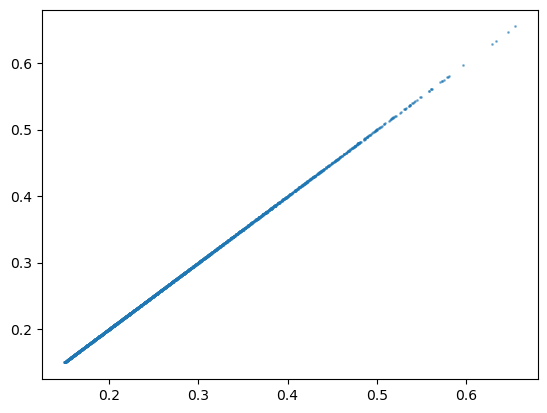

In [ ]:
plt.scatter(fev, dat['fev'][ineur], s=1, alpha=0.5)

fullmodel feve: 0.7015602588653564
gabor feve: 0.24144558608531952


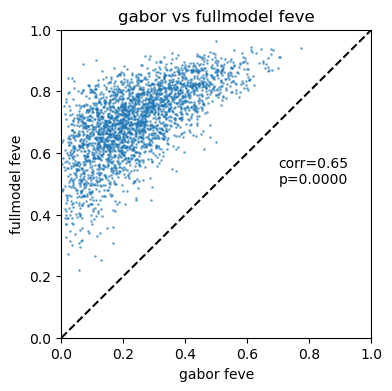

In [ ]:
valid_idxes = np.where(feve > 0.)[0]
fig, ax = plt.subplots(1, 1, figsize=(4,4))
plt.scatter(feve[valid_idxes], fullmodel_feve[valid_idxes], s=1, alpha=0.5)
print(f'fullmodel feve: {fullmodel_feve[valid_idxes].mean()}')
print(f'gabor feve: {feve[valid_idxes].mean()}')
plt.xlabel('gabor feve')
plt.ylabel('fullmodel feve')
plt.title('gabor vs fullmodel feve')
r, p = pearsonr(feve[valid_idxes], fullmodel_feve[valid_idxes])
plt.text(0.7, 0.5, f'corr={r:.2f}\np={p:.4f}', transform=plt.gca().transAxes)
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot([0,1], [0,1], 'k--')
plt.show()

fullmodel feve: 0.6959583759307861
gabor feve: 0.27834585309028625


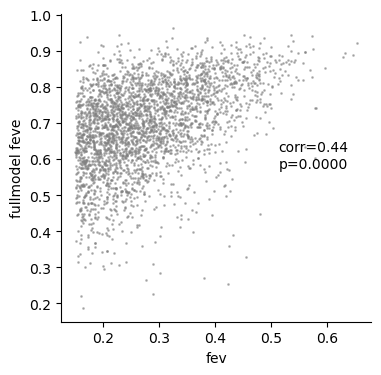

In [ ]:
# valid_idxes = np.where(feve > 0.)[0]
valid_idxes = np.arange(len(feve))
fig, ax = plt.subplots(1, 1, figsize=(4,4))
plt.scatter(fev[valid_idxes], fullmodel_feve[valid_idxes], s=1, alpha=0.5, color='gray')
print(f'fullmodel feve: {fullmodel_feve[valid_idxes].mean()}')
print(f'gabor feve: {fev[valid_idxes].mean()}')
plt.xlabel('fev')
plt.ylabel('fullmodel feve')
# plt.title('fullmodel feve vs fev')
from scipy.stats import pearsonr
r, p = pearsonr(fev[valid_idxes], fullmodel_feve[valid_idxes])
plt.text(0.7, 0.5, f'corr={r:.2f}\np={p:.4f}', transform=plt.gca().transAxes)
# plt.xlim(0,1)
# plt.ylim(0,1)
# plt.plot([0,1], [0,1], 'k--')
# set right spine invisible
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

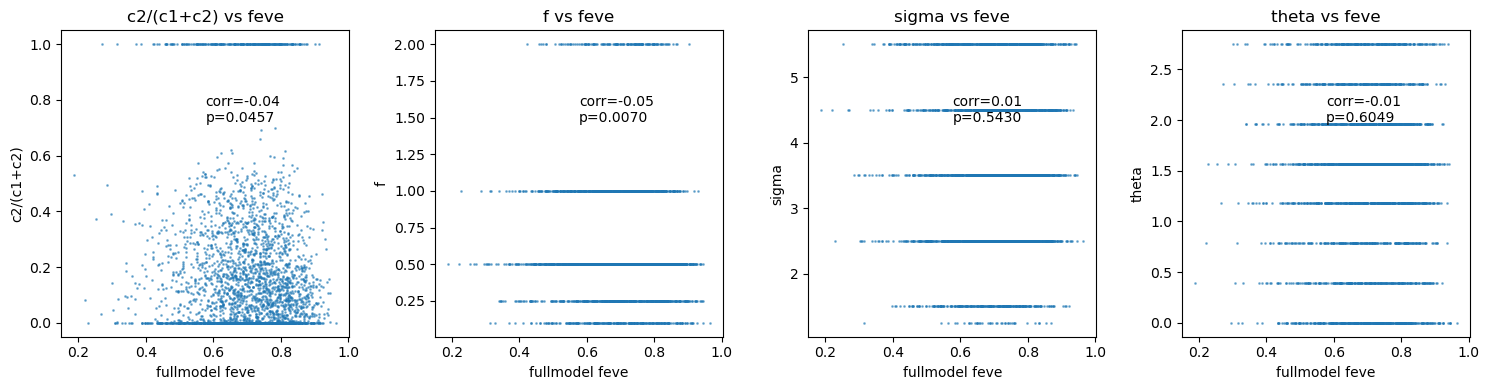

In [ ]:
params = [cratio, mf.cpu().numpy().squeeze(), msigma.cpu().numpy().squeeze(), mtheta.cpu().numpy().squeeze()]
titles = ['c2/(c1+c2)', 'f', 'sigma', 'theta']
from scipy import stats
fig, ax = plt.subplots(1, 4, figsize=(15,4))
for i, axi in enumerate(ax):
    axi.scatter(fullmodel_feve[valid_idxes], params[i][valid_idxes], s=1, alpha=0.5)
    axi.set_ylabel(titles[i])
    axi.set_xlabel('fullmodel feve')
    axi.set_title(f'{titles[i]} vs feve')
    # pearson correlation and p-value
    corr, p = stats.pearsonr(params[i][valid_idxes], fullmodel_feve[valid_idxes])
    axi.text(0.5, 0.7, f'corr={corr:.2f}\np={p:.4f}', transform=axi.transAxes)
plt.tight_layout()
plt.show()

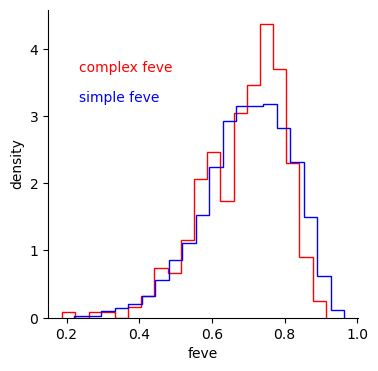

In [ ]:
param = params[0]
icomplex = np.where(param > 0.5)[0]
isimple = np.where(param <= 0.5)[0]

fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.hist(fullmodel_feve[icomplex], bins=20, alpha=1, label='complex', density=True, color='r', histtype='step')
ax.text(0.1, 0.8, f'complex feve', transform=ax.transAxes, color='r')
ax.hist(fullmodel_feve[isimple], bins=20, alpha=1, label='simple', density=True, color='b', histtype='step')
ax.text(0.1, 0.7, f'simple feve', transform=ax.transAxes, color='b')

ax.set_xlabel('feve')
ax.set_ylabel('density')
# set right spine invisible
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.legend()
plt.show()


/tmp/ipykernel_523073/958652514.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(val) + 1)


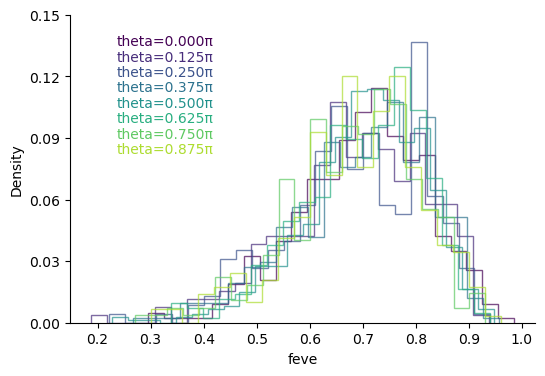

In [ ]:
param = params[1]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.get_cmap('viridis', len(val) + 1)

fixed_bar_width = 0.03  # Set a fixed bar width for all distributions

# Iterate over the unique values in the parameter array
for i, v in enumerate(val):
    # Get data for the current parameter value
    data = fullmodel_feve[param == v]
    
    # Calculate bins to ensure consistent bar width
    min_data, max_data = np.min(data), np.max(data)
    bins = np.arange(min_data, max_data + fixed_bar_width, fixed_bar_width)
    
    # Plot histogram with the fixed bar width
    ax.hist(data, bins=bins, alpha=0.7, label=f'{titles[k]}={v:.1f}', 
            density=True, histtype='step', color=cmap(i))
    
    # Add information text
    ax.text(0.1, 0.9 - i * 0.05, 
            f'{titles[k]}={v / np.pi:.3f}π', 
            transform=ax.transAxes, color=cmap(i))
ax.set_yticks(np.arange(5), [f'{i*fixed_bar_width:.2f}' for i in np.arange(5)])
# Customize plot
ax.set_xlabel('feve')
ax.set_ylabel('Density')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

0.313231 0.8670907
0.39807075 0.92132926
0.2274006 0.9638221
0.2856199 0.9446599
0.18827128 0.93400276
0.25300086 0.9429911


/tmp/ipykernel_523073/2416246734.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(val) + 1)


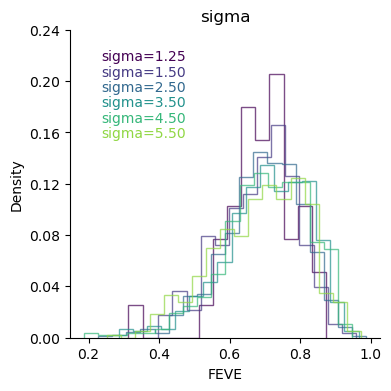

In [ ]:
k = 2
param = params[k]
val, cts = np.unique(param, return_counts=True)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.set_title(f'{titles[k]}')
fixed_bar_width = 0.04  # Set a fixed bar width for all distributions
cmap = plt.cm.get_cmap('viridis', len(val) + 1)
# Iterate over the unique values in the parameter array
for i, v in enumerate(val):
    # Get data for the current parameter value
    data = fullmodel_feve[param == v]
    
    # Calculate bins to ensure consistent bar width
    min_data, max_data = np.min(data), np.max(data)
    print(min_data, max_data)
    bins = np.arange(min_data, max_data + fixed_bar_width, fixed_bar_width)
    
    # Plot histogram with the fixed bar width
    ax.hist(data, bins=bins, alpha=0.7, label=f'{titles[k]}={v:.1f}', 
            density=True, histtype='step', color=cmap(i))
    
    # Add information text
    if k == 3:
        ax.text(0.1, 0.9 - i * 0.05, 
                f'{titles[k]}={v / np.pi:.3f}π', 
                transform=ax.transAxes, color=cmap(i))
    else:
        ax.text(0.1, 0.9 - i * 0.05, 
                f'{titles[k]}={v:.2f}', 
                transform=ax.transAxes, color=cmap(i))
ms = [0,6,7,6]
m = ms[k]
ax.set_yticks(np.arange(m), [f'{i*fixed_bar_width:.2f}' for i in np.arange(m)])
ax.set_xlabel('FEVE')
ax.set_ylabel('Density')
# set right spine invisible
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.legend()
plt.show()

In [ ]:
len(fev)

3040

In [ ]:
d

NameError: name 'd' is not defined